# Bayesian Uncertainty Minimization

This demo shows how to minimize the uncertainty of a simple 1D function using Bayesian optimization with a GPR as the surrogate model. The GPR can use derivative information to aid in the regression.

In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

sys.path.append("../..")
import gpder 
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernelDerAware, GPKernel
from gpder.bayes import UncertaintyOptimization
from gpder.bayes.minimizers import hybrid_minimizer

from sklearn.metrics import mean_squared_error

from utils import plot_gpr_evolution, plot_gpr_iterloss
from utils import grid_sampling


We regress the same function as in the 'Gaussian Process' demo, but instead of randomly selecting training points for the GPR, we rely on a Bayesian optimization to find the training points which minimize the uncertainty of the model.

In [2]:
def F(X, s=0.1):
    noise = s * np.random.uniform(-1, 1)
    return X * np.sin(4*np.pi * X**2) + s

And pick five random training points to initialize the training.

In [3]:
np.random.seed(123)
X_train = np.random.uniform(0, 1, 5).reshape(-1, 1)

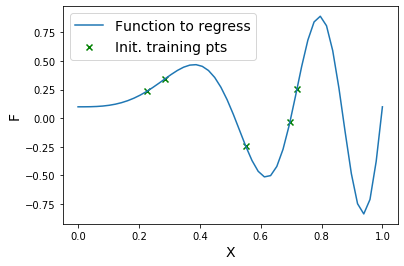

In [4]:
np.random.seed(1)

X_lower = 0 
X_upper = 1
X_star = np.linspace(X_lower, X_upper, 50)
y_star = F(X_star)

plt.plot(X_star, y_star, label='Function to regress')
plt.scatter(X_train, F(X_train), label='Init. training pts', color='g', marker='x')
plt.xlabel("X", fontsize=14)
plt.ylabel("F", fontsize=14)
plt.legend(fontsize=14)
plt.show()

## Regular GPR

We begin by minimizing the uncertainty of a regular GPR regression.

To kick off the search, we begin with one randomly selected training point. With every iteration, we sample the point which is predicted to minimize the uncertainty. That is, the nth point is chosen to minimize the uncertainty of the model with n-training points.

| Iter | X           | Target      | Uncert train| MSE test    | Uncert test |
| 1    | 0.696469    | -0.029909   | 0.309604    | 0.134436    | 2.396532    |
| 2    | 0.286139    | 0.345142    | 0.309604    | 0.134436    | 2.396532    |
| 3    | 0.226851    | 0.236688    | 0.309604    | 0.134436    | 2.396532    |
| 4    | 0.551315    | -0.245775   | 0.309604    | 0.134436    | 2.396532    |
| 5    | 0.719469    | 0.258144    | 0.309604    | 0.134436    | 2.396532    |
| 6    | 1.000000    | 0.100000    | 0.310568    | 0.142159    | 2.017558    |
| 7    | 0.000000    | 0.100000    | 0.315945    | 0.142774    | 1.752973    |
| 8    | 0.860113    | 0.210004    | 0.358553    | 0.139635    | 1.322268    |
| 9    | 0.411729    | 0.448956    | 0.568745    | 0.165089    | 2.341072    |
| 10   | 0.814935    | 0.818436    | 1.238578    | 0.171893    | 4.431632    |
| 11   | 0.630976    | -0.504508   | 1.793658    | 0.027574    | 1.301484    |
| 12   | 0.103669    | 0.113958    | 1.789564    | 0

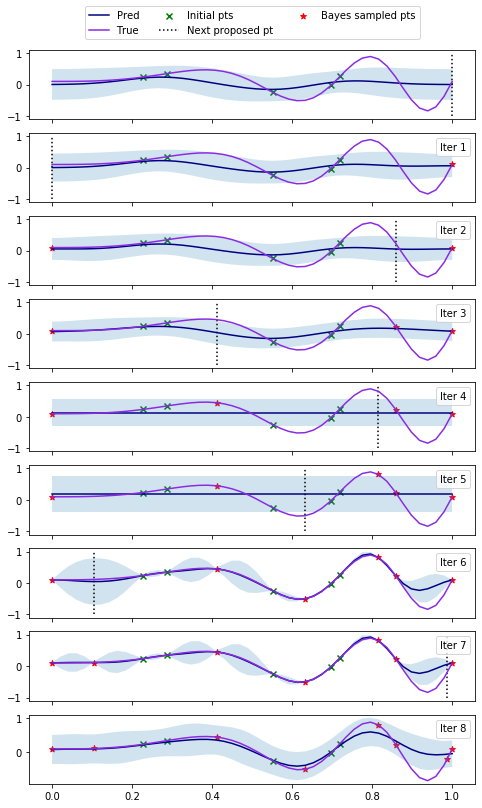

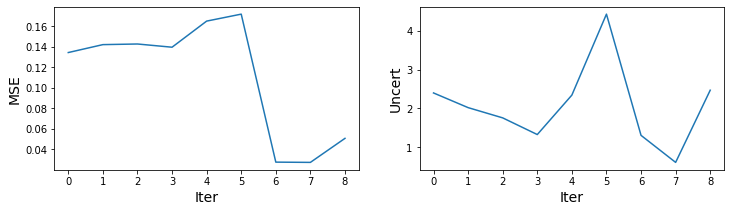

In [5]:
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel, 
                              n_restarts_optimizer=10,
                              ignore_convergence_warnings=True,
                              random_state=123)
bayes = UncertaintyOptimization(GaussianProcessRegressor=gp,
                                fun=F,
                                verbose=True,
                                param_bounds={'X': (0, 1)},
                                random_state=123)
bayes.minimize_uncertainty(#nrand_train=5,
                           params_train=X_train,
                           params_test=X_star.reshape(-1, 1),
                           niters=8,
                           minimizer_restarts=5)

reg_mse = bayes.mse_test
reg_uncert = bayes.uncert_test

# plot the bayesian search at every iteration
plot_gpr_evolution(bayes=copy.deepcopy(bayes), 
                   save_to="reg_gpr_evol_2.png")

# and the MSE, Uncertainty per iteration
plot_gpr_iterloss(mse=reg_mse, 
                  uncert=reg_uncert,
                  save_to="reg_metricsvsiter_2.png")

Without optimizing the GP

In [6]:
# -- get initial GP parameters-- #
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10,
                              ignore_convergence_warnings=True,
                              random_state=123)
gp.fit(X_train, F(X_train))
c = gp.kernel_.constant_value
l = gp.kernel_.length_scale
n = gp.kernel_.noise_level

| Iter | X           | Target      | Uncert train| MSE test    | Uncert test |
| 1    | 0.696469    | -0.029909   | 0.309604    | 0.134436    | 2.396532    |
| 2    | 0.286139    | 0.345142    | 0.309604    | 0.134436    | 2.396532    |
| 3    | 0.226851    | 0.236688    | 0.309604    | 0.134436    | 2.396532    |
| 4    | 0.551315    | -0.245775   | 0.309604    | 0.134436    | 2.396532    |
| 5    | 0.719469    | 0.258144    | 0.309604    | 0.134436    | 2.396532    |
| 6    | 0.696469    | -0.029909   | 0.371525    | 0.134021    | 2.378824    |
| 7    | 0.423106    | 0.429309    | 0.433446    | 0.113624    | 2.248647    |
| 8    | 0.343178    | 0.441763    | 0.495367    | 0.112238    | 2.211959    |
| 9    | 0.737995    | 0.492593    | 0.557288    | 0.095572    | 2.179243    |
| 10   | 0.634401    | -0.496991   | 0.619209    | 0.083729    | 2.147644    |
| 11   | 0.322959    | 0.412097    | 0.681130    | 0.083483    | 2.133607    |
| 12   | 0.092105    | 0.109800    | 0.743051    | 0

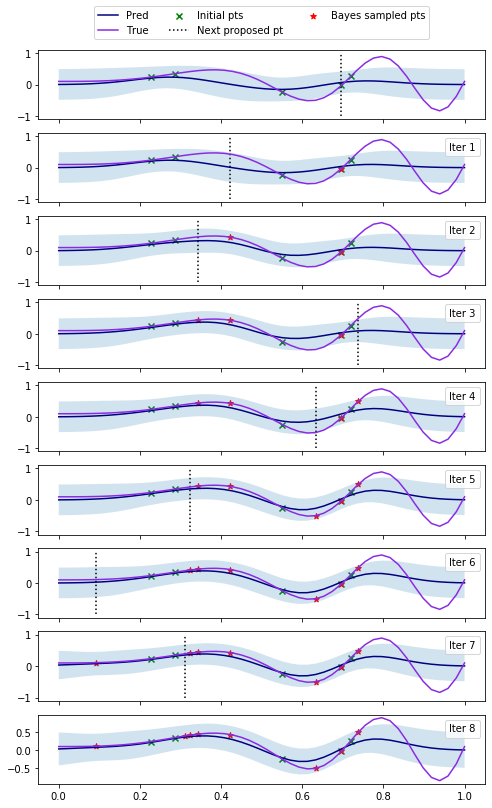

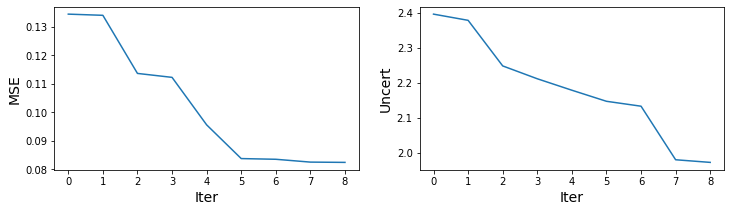

In [17]:
# -- get initial GP parameters-- #
kernel = GPKernel(constant_value=c, length_scale=l, noise_level=n)
gp = GaussianProcessRegressor(kernel=kernel,
                              optimizer=None,
                              #n_restarts_optimizer=10,
                              ignore_convergence_warnings=True,
                              random_state=123)
bayes_reg = UncertaintyOptimization(GaussianProcessRegressor=gp,
                                fun=F,
                                verbose=True,
                                param_bounds={'X': (0, 1)},
                                random_state=123)
bayes_reg.minimize_uncertainty(params_train=X_train,
                           params_test=X_star.reshape(-1, 1),
                           niters=8,
                           minimizer_restarts=5)

reg_mse = bayes_reg.mse_test
reg_uncert = bayes_reg.uncert_test

# plot the bayesian search at every iteration
plot_gpr_evolution(bayes=copy.deepcopy(bayes_reg), 
                   save_to="reg_gpr_evol_2.png")

# and the MSE, Uncertainty per iteration
plot_gpr_iterloss(mse=reg_mse, 
                  uncert=reg_uncert,
                  save_to="reg_metricsvsiter_2.png")

And now let's compare the results to uniformly sampling points.

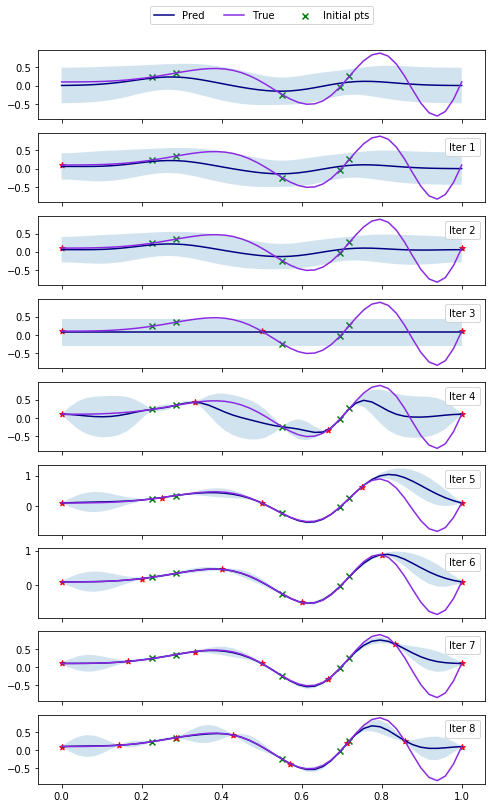

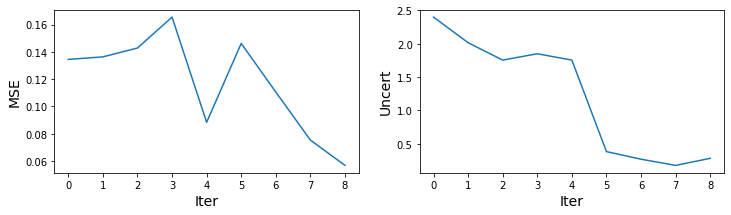

In [9]:
grid_mse, grid_uncert = grid_sampling(niters=8, 
                                      x_init=bayes.init_params, 
                                      x_val=X_star, 
                                      bound_low=0, bound_high=1,
                                      fun=F,
                                      save_to='grid_gpr_evol.png')

plot_gpr_iterloss(grid_mse, grid_uncert, save_to='grid_metricsvsiter')

## Derivative-enhanced GPR

In [9]:
def dF(X, s=0.1):
    noise = s * np.random.uniform(-1, 1)
    return np.sin(4*np.pi * X**2) + X * np.cos(4*np.pi * X**2) * (8*np.pi * X) + s

In [10]:
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel, 
                              n_restarts_optimizer=10,
                              ignore_convergence_warnings=True,
                              random_state=123)
bayes = UncertaintyOptimization(GaussianProcessRegressor=gp,
                                fun=F,
                                dfun=dF,
                                verbose=True,
                                param_bounds={'X': (0, 1)},
                                random_state=123)
bayes.minimize_uncertainty(params_train=X_train,
                           params_test=X_star.reshape(-1, 1),
                           niters=8,
                           minimizer_restarts=5)

der_mse = bayes.mse_test
der_uncert = bayes.uncert_test

plot_gpr_evolution(bayes=copy.deepcopy(bayes), 
                   save_to="der_gpr_evol_2.png")
plot_gpr_iterloss(der_mse, der_uncert,
                  save_to="der_metricsvsiter_2.png")

| Iter | X           | Target      | Uncert train| MSE test    | Uncert test |
| 1    | 0.696469    | -0.029909   | 1.712375    | 0.177286    | 4.748790    |
| 2    | 0.286139    | 0.345142    | 1.712375    | 0.177286    | 4.748790    |
| 3    | 0.226851    | 0.236688    | 1.712375    | 0.177286    | 4.748790    |
| 4    | 0.551315    | -0.245775   | 1.712375    | 0.177286    | 4.748790    |
| 5    | 0.719469    | 0.258144    | 1.712375    | 0.177286    | 4.748790    |
| 6    | 1.000000    | 0.100000    | 4.416063    | 0.009647    | 11.063465   |
| 7    | 0.486546    | 0.180777    | 8.322163    | 0.021269    | 9.966468    |
| 8    | 0.409878    | 0.451481    | 20.036409   | 0.007231    | 11.645883   |
| 9    | 0.000000    | 0.100000    | 19.689196   | 0.000847    | 2.980016    |
| 10   | 0.872657    | -0.026003   | 11.894798   | 0.000103    | 1.186112    |
| 11   | 0.115255    | 0.119150    | 13.879529   | 0.000073    | 0.150228    |
| 12   | 0.000000    | 0.100000    | 11.617827   | 0

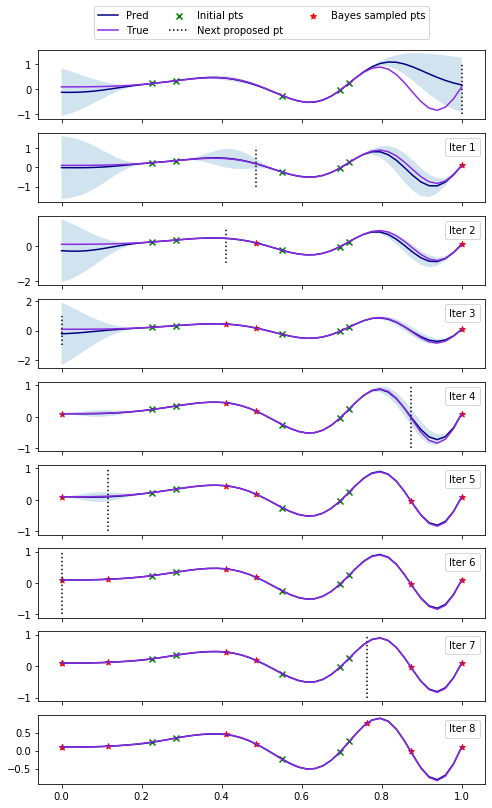

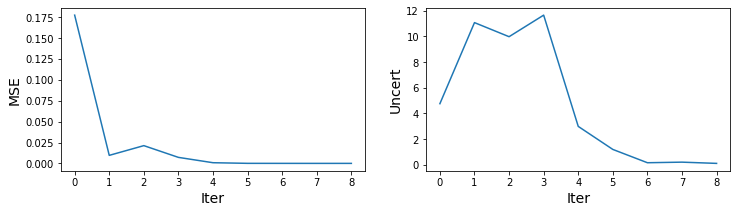

In [11]:
der_mse = bayes.mse_test
der_uncert = bayes.uncert_test

plot_gpr_evolution(bayes=copy.deepcopy(bayes), 
                   save_to="der_gpr_evol_2.png")
plot_gpr_iterloss(der_mse, der_uncert,
                  save_to="der_metricsvsiter_2.png")

| Iter | X           | Target      | Uncert train| MSE test    | Uncert test |
| 1    | 0.696469    | -0.029909   | 0.309604    | 0.076545    | 2.396532    |
| 2    | 0.286139    | 0.345142    | 0.309604    | 0.076545    | 2.396532    |
| 3    | 0.226851    | 0.236688    | 0.309604    | 0.076545    | 2.396532    |
| 4    | 0.551315    | -0.245775   | 0.309604    | 0.076545    | 2.396532    |
| 5    | 0.719469    | 0.258144    | 0.309604    | 0.076545    | 2.396532    |
| 6    | 0.696469    | -0.029909   | 0.371525    | 0.076133    | 2.378824    |
| 7    | 0.423106    | 0.429309    | 0.433446    | 0.072210    | 2.248647    |
| 8    | 0.343178    | 0.441763    | 0.495367    | 0.071411    | 2.211959    |
| 9    | 0.737995    | 0.492593    | 0.557288    | 0.082876    | 2.179243    |
| 10   | 0.634401    | -0.496991   | 0.619209    | 0.083783    | 2.147644    |
| 11   | 0.322959    | 0.412097    | 0.681130    | 0.083375    | 2.133607    |
| 12   | 0.092105    | 0.109800    | 0.743051    | 0

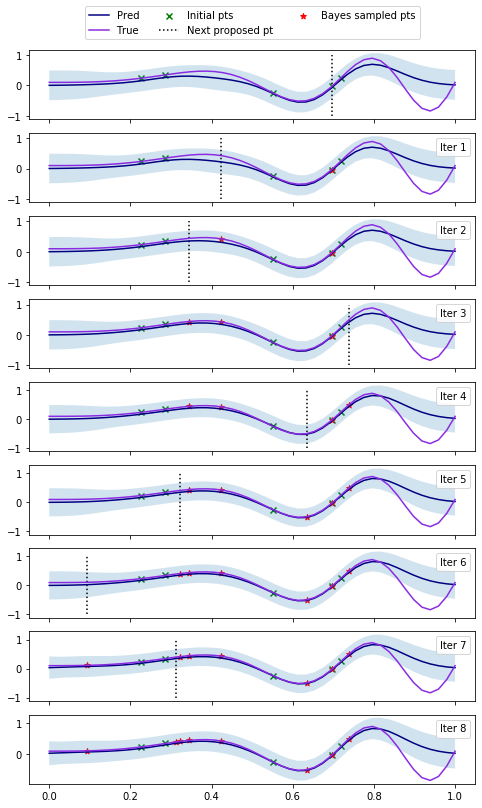

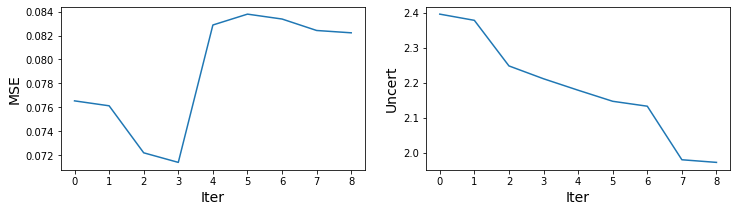

In [18]:
kernel = GPKernelDerAware(constant_value=c, length_scale=l, noise_level_X=n)
gp = GaussianProcessRegressor(kernel=kernel,
                              optimizer=None,
                              #n_restarts_optimizer=10,
                              ignore_convergence_warnings=True,
                              random_state=123)
bayes_der = UncertaintyOptimization(GaussianProcessRegressor=gp,
                                fun=F,
                                dfun=dF,
                                verbose=True,
                                param_bounds={'X': (0, 1)},
                                random_state=123)
bayes_der.minimize_uncertainty(params_train=X_train.reshape(-1, 1),
                           params_test=X_star.reshape(-1, 1),
                           niters=8,
                           minimizer_restarts=5)

reg_mse = bayes_der.mse_test
reg_uncert = bayes_der.uncert_test

# plot the bayesian search at every iteration
plot_gpr_evolution(bayes=copy.deepcopy(bayes_der), 
                   save_to="reg_gpr_evol_2.png")

# and the MSE, Uncertainty per iteration
plot_gpr_iterloss(mse=reg_mse, 
                  uncert=reg_uncert,
                  save_to="reg_metricsvsiter_2.png")